In [1]:
import json
import pandas as pd

with open("../../dataset/train_sentiment.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df1 = pd.DataFrame(data)

# print(df.head())

In [2]:
df2 = pd.read_csv('../../dataset/review_shopping.csv', sep='\t', names=['text', 'sentiment'], header=None)
df2['sentiment'] = df2['sentiment'].replace({
    'neg': 'negative',
    'pos': 'positive'
})

<Axes: xlabel='sentiment'>

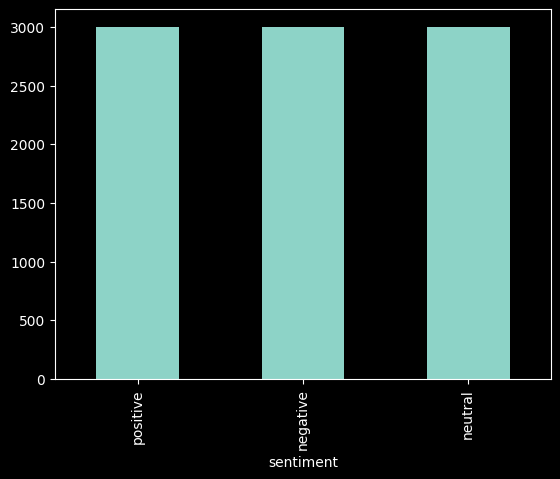

In [3]:
df = pd.concat([df1], ignore_index=True)
df['sentiment'].value_counts().plot.bar()

In [4]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [5]:
from models.preprocess import clean_text
text = df['text']
sentiment = df['sentiment']

# text = df["text"].apply(clean_text)
text.head()

0    มาตามนัด 🚮🗑️ . . #เขตพญาไท #กรุงเทพมหานคร @สาย...
1    &#9888; แยกราชเทวีจะรื้อน้ำพุกี่โมง? &#128591;...
2    &#128308;สด!"ไอซ์ รักชนก" แถลงข่าวการประมูลคลื...
3    &#127808;#เขตหนองจอก >>ติดตามการดำเนินงานโครงก...
4    ไทวัสดุ ส่งช่างมือ 1 วีฟิกซ์ ร่วมฟื้นฟู ปรับภู...
Name: text, dtype: object

In [6]:
from sklearn.model_selection import train_test_split

text_train, text_val, sentiment_train, sentiment_val = train_test_split(
    text, sentiment, test_size=0.2, random_state=42
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from models.preprocess import tokenizer

vectorizer = TfidfVectorizer(
    tokenizer=tokenizer,
    ngram_range=(1,2),
)

text_train_tfidf = vectorizer.fit_transform(text_train)
text_val_tfidf = vectorizer.transform(text_val)

c:\Users\Jin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [8]:
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.5)

model.fit(text_train_tfidf, sentiment_train)

LinearSVC(C=1.5)

In [9]:
from sklearn.metrics import accuracy_score, classification_report # type: ignore

y_pred = model.predict(text_val_tfidf)

print("Accuracy:", accuracy_score(sentiment_val, y_pred))
print(classification_report(sentiment_val, y_pred))

Accuracy: 0.8016666666666666
              precision    recall  f1-score   support

    negative       0.83      0.85      0.84       611
     neutral       0.76      0.72      0.74       617
    positive       0.81      0.83      0.82       572

    accuracy                           0.80      1800
   macro avg       0.80      0.80      0.80      1800
weighted avg       0.80      0.80      0.80      1800



In [10]:
import pickle

with open("../../models/SVM/sentiment_model.pkl", "wb") as f:
    pickle.dump((vectorizer, model), f)

In [11]:
import pickle

with open("sentiment_model.pkl", "rb") as f:
    vectorizer, model = pickle.load(f)

test_text = "ไป ตาย ไป"

vec = vectorizer.transform([test_text])
prediction = model.predict(vec)

print("Prediction:", prediction[0])

Prediction: neutral
